# istat-housing-crowding â€” notebook v0

Notebook v0 di validazione del mart in `dataset-incubator`.

- scopo: sanity check e lettura base del mart
- non sostituisce l'analisi pubblica
- evita output pesanti o immagini embeddate nel commit


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SLUG = "istat-housing-crowding"
DATASET_NAME = "istat_housing_crowding"
MART_TABLE = "mart_crowding_tenure_italy"
METRICA = "componenti_per_100mq"

candidate_dir = Path.cwd()
if not (candidate_dir / "dataset.yml").exists():
    if (candidate_dir.parent / "dataset.yml").exists():
        candidate_dir = candidate_dir.parent
    else:
        raise FileNotFoundError(
            f"dataset.yml non trovato in {Path.cwd()} o nella cartella parent."
        )

mart_root = candidate_dir.parents[1] / "out" / "data" / "mart" / DATASET_NAME
mart_candidates = sorted(mart_root.glob(f"*/{MART_TABLE}.parquet"))
if not mart_candidates:
    raise FileNotFoundError(
        f"Mart non trovato per {DATASET_NAME}: atteso in out/data/mart/{DATASET_NAME}/.../{MART_TABLE}.parquet"
    )

PARQUET_PATH = mart_candidates[-1]
print(f"Mart selezionato: out/data/mart/{DATASET_NAME}/{PARQUET_PATH.parent.name}/{MART_TABLE}.parquet")


Mart selezionato: out/data/mart/istat_housing_crowding/2024/mart_crowding_tenure_italy.parquet


In [2]:
con = duckdb.connect()
df = con.execute("SELECT * FROM read_parquet(?)", [str(PARQUET_PATH)]).df()
print(f"Shape: {df.shape}")
display(df.dtypes)


Shape: (42, 4)


anno                      int32
ref_area                    str
titolo_godimento            str
componenti_per_100mq    float64
dtype: object

In [3]:
display(df.head(10))


,anno,ref_area,titolo_godimento,componenti_per_100mq
0,2004,Italy,property,2.8
1,2004,Italy,rent,3.4
2,2005,Italy,property,2.7
3,2005,Italy,rent,3.4
4,2006,Italy,property,2.7
5,2006,Italy,rent,3.4
6,2007,Italy,property,2.7
7,2007,Italy,rent,3.3
8,2008,Italy,property,2.7
9,2008,Italy,rent,3.2


In [4]:
print("Null per colonna:")
display(df.isnull().sum())

negativi = int((df[METRICA] < 0).sum()) if pd.api.types.is_numeric_dtype(df[METRICA]) else "n/a"
print(f"\nRange {METRICA}: min={df[METRICA].min()}, max={df[METRICA].max()}, negativi={negativi}")


Null per colonna:


anno                    0
ref_area                0
titolo_godimento        0
componenti_per_100mq    0
dtype: int64


Range componenti_per_100mq: min=2.4, max=3.4, negativi=0


In [5]:
wide = (
    df.pivot(index="anno", columns="titolo_godimento", values=METRICA)
    .reset_index()
    .sort_values("anno")
)
if "rent" in wide.columns and "property" in wide.columns:
    wide["gap_affitto_meno_proprieta"] = wide["rent"] - wide["property"]
display(wide)


titolo_godimento,anno,property,rent,gap_affitto_meno_proprieta
0,2004,2.8,3.4,0.6
1,2005,2.7,3.4,0.7
2,2006,2.7,3.4,0.7
3,2007,2.7,3.3,0.6
4,2008,2.7,3.2,0.5
5,2009,2.6,3.2,0.6
6,2010,2.6,3.3,0.7
7,2011,2.6,3.3,0.7
8,2012,2.6,3.3,0.7
9,2013,2.6,3.4,0.8


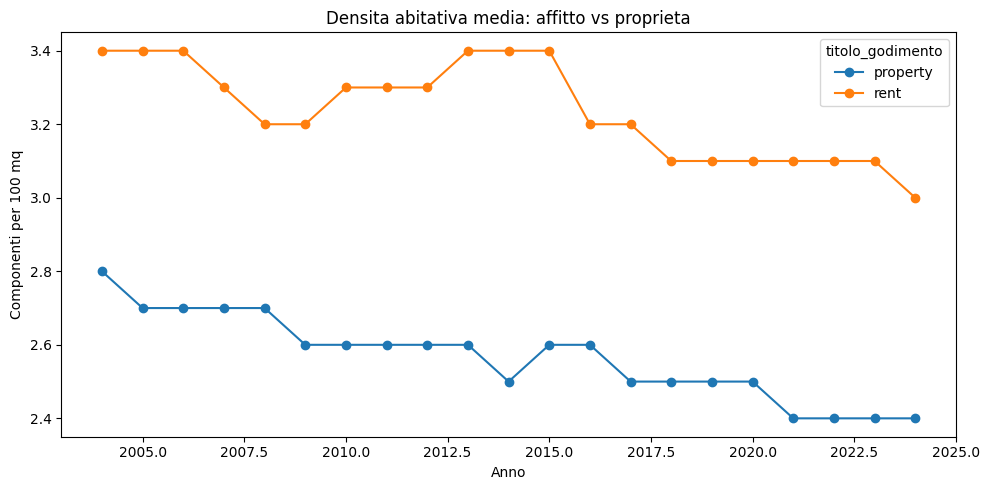

In [6]:
ax = (
    df.pivot(index="anno", columns="titolo_godimento", values=METRICA)
    .sort_index()
    .plot(marker="o", figsize=(10, 5), title="Densita abitativa media: affitto vs proprieta")
)
ax.set_ylabel("Componenti per 100 mq")
ax.set_xlabel("Anno")
plt.tight_layout()
plt.show()


## Note v0

- Slug: `istat-housing-crowding`
- Tabella mart: `mart_crowding_tenure_italy`
- Metrica guida: `componenti_per_100mq`
- Perimetro: Italia totale, titolo di godimento `rent` vs `property`, serie annuale del flow `33_179`
- Questo notebook resta esplorativo e validativo in DI.
